# Exploratory Data Analysis — Iris Dataset

**Goal:** understand the structure of the dataset, clean it, spot anomalies,
and validate assumptions before any modeling — using summary statistics
and visualizations.

**Dataset:** Iris flower measurements (150 samples, 3 species), loaded from
`data/iris.csv`. This CSV was derived from `sklearn.datasets.load_iris`
with a few realistic data-quality issues intentionally injected (missing
values, one duplicate row) so the cleaning steps below have something real
to do. See `generate_sample_data.py` for exactly how it was built.

**Sections**
1. Load & inspect structure
2. Data cleaning (missing values, duplicates, types)
3. Summary statistics
4. Univariate distributions
5. Relationships between features (by species)
6. Correlation analysis
7. Outlier detection
8. Automated profiling report (ydata-profiling)
9. Key insights


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("data/iris.csv")
df.head()


   sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm species
0              5.1             3.5              1.4             0.2  setosa
1              4.9             3.0              1.4             0.2  setosa
2              4.7             3.2              1.3             0.2  setosa
3              4.6             3.1              1.5             0.2  setosa
4              5.0             3.6              1.4             0.2  setosa

## 1. Load & inspect structure

In [2]:
print("Shape (rows, cols):", df.shape)
df.info()


Shape (rows, cols): (151, 5)
<class 'pandas.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length_cm  151 non-null    float64
 1   sepal_width_cm   151 non-null    float64
 2   petal_length_cm  151 non-null    float64
 3   petal_width_cm   145 non-null    float64
 4   species          151 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [3]:
df.dtypes


sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
species                str
dtype: object

**Observation:** 4 numeric measurement columns (`sepal_length_cm`,
`sepal_width_cm`, `petal_length_cm`, `petal_width_cm`) and one categorical
target column (`species`) with 3 classes.

## 2. Data cleaning

In [4]:
# Missing values per column
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


                 missing_count  missing_pct
sepal_length_cm              0         0.00
sepal_width_cm               0         0.00
petal_length_cm              0         0.00
petal_width_cm               6         3.97
species                      0         0.00

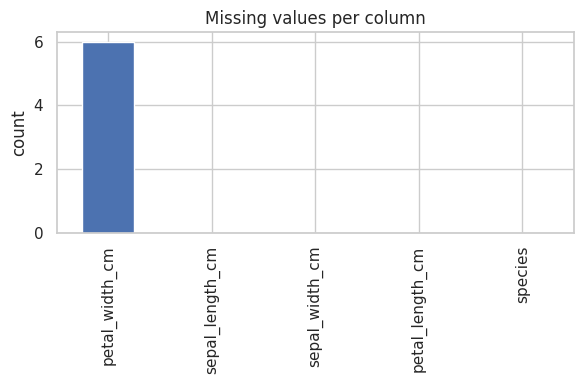

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
missing.sort_values(ascending=False).plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Missing values per column")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()


`petal_width_cm` has a handful of missing values. For this dataset size
(~150 rows) and a numeric feature with a roughly symmetric distribution,
**median imputation** is a reasonable, low-risk default — it won't be
skewed by outliers the way mean imputation would. We keep the original
column and add an imputed version so the effect of imputation stays
inspectable.

In [6]:
df["petal_width_cm_imputed"] = df["petal_width_cm"].fillna(df["petal_width_cm"].median())

# Duplicate rows
n_dupes = df.duplicated(subset=[c for c in df.columns if c != "petal_width_cm_imputed"]).sum()
print(f"Duplicate rows found: {n_dupes}")
df_clean = df.drop_duplicates(subset=[c for c in df.columns if c != "petal_width_cm_imputed"]).reset_index(drop=True)
print("Shape after dropping duplicates:", df_clean.shape)


Duplicate rows found: 2
Shape after dropping duplicates: (149, 6)


## 3. Summary statistics

In [7]:
df_clean.describe()


       sepal_length_cm  sepal_width_cm  petal_length_cm  petal_width_cm  \
count       149.000000      149.000000       149.000000       143.00000   
mean          5.843624        3.059732         3.748993         1.18042   
std           0.830851        0.436342         1.767791         0.75975   
min           4.300000        2.000000         1.000000         0.10000   
25%           5.100000        2.800000         1.600000         0.30000   
50%           5.800000        3.000000         4.300000         1.30000   
75%           6.400000        3.300000         5.100000         1.80000   
max           7.900000        4.400000         6.900000         2.50000   

       petal_width_cm_imputed  
count              149.000000  
mean                 1.185235  
std                  0.744564  
min                  0.100000  
25%                  0.300000  
50%                  1.300000  
75%                  1.800000  
max                  2.500000  

In [8]:
df_clean["species"].value_counts()


species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

**Observation:** classes are well balanced (~50 samples each), so accuracy
would be a reasonable metric if this became a classification task later —
no resampling needed.

## 4. Univariate distributions

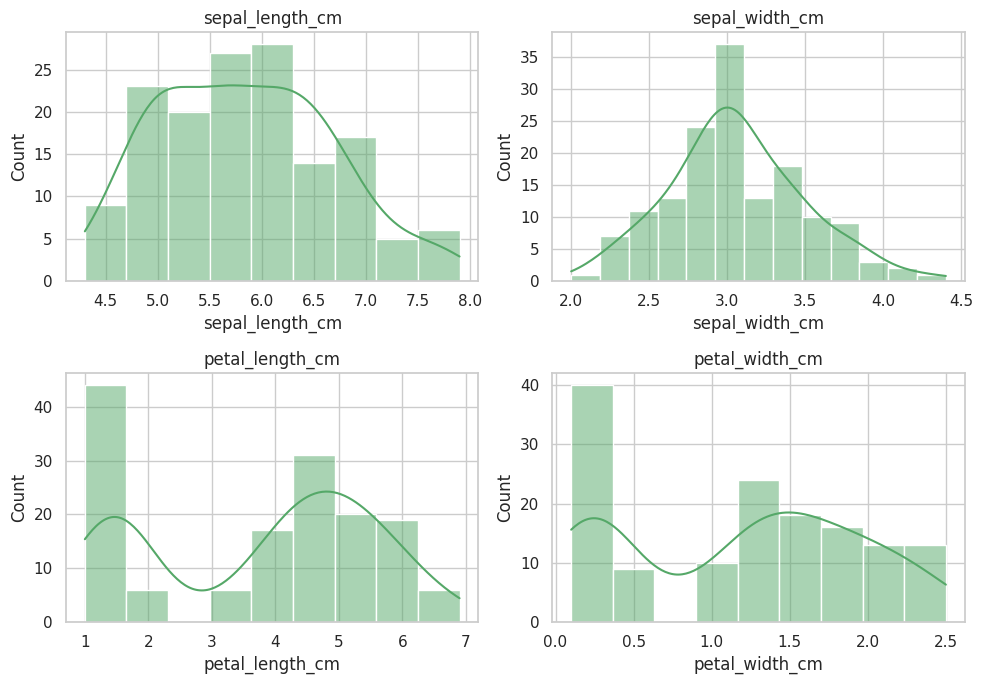

In [9]:
num_cols = ["sepal_length_cm", "sepal_width_cm", "petal_length_cm", "petal_width_cm"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df_clean[col].dropna(), kde=True, ax=ax, color="#55A868")
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Observation:** `petal_length_cm` and `petal_width_cm` are clearly
bimodal/multimodal — a strong early signal that these two features
separate the species well (confirmed in Section 5). `sepal_width_cm`
looks closest to a normal distribution.

## 5. Relationships between features (by species)

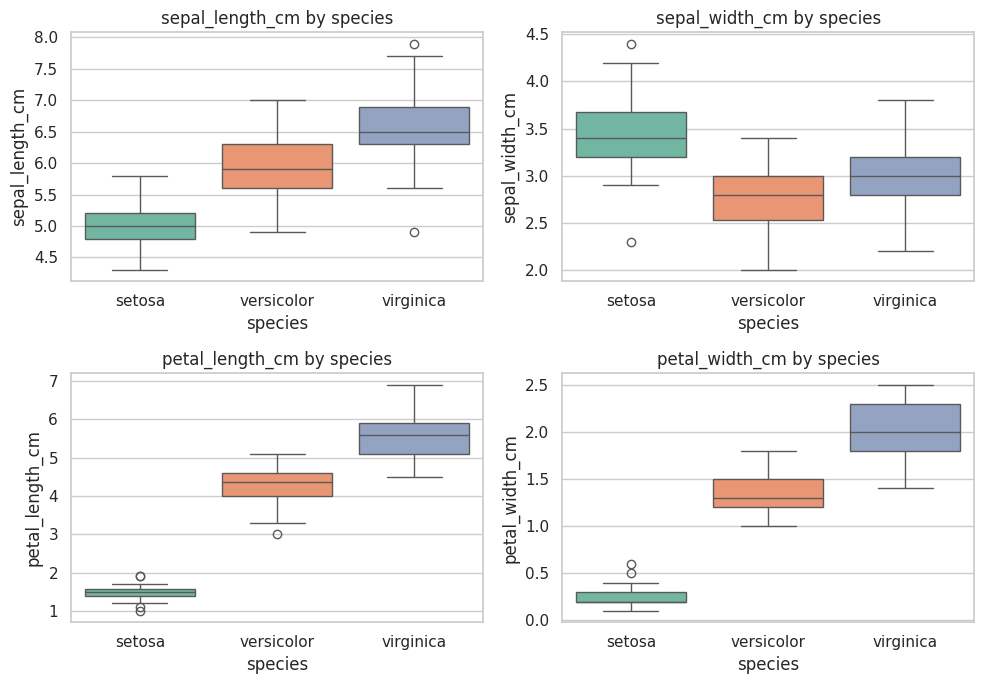

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df_clean, x="species", y=col, hue="species", legend=False, palette="Set2", ax=ax)
    ax.set_title(f"{col} by species")
plt.tight_layout()
plt.show()


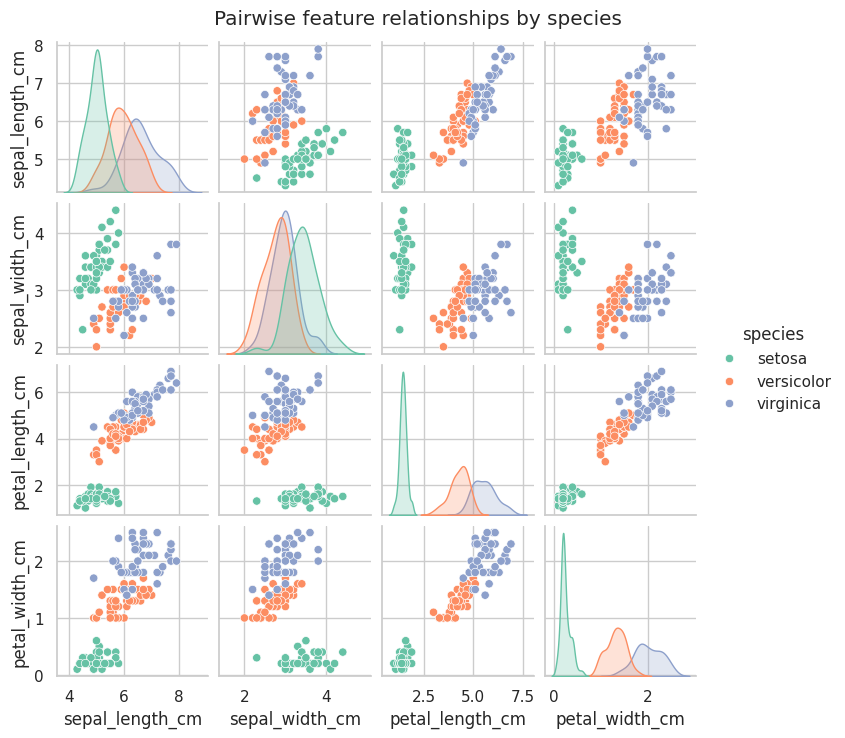

In [11]:
g = sns.pairplot(df_clean.dropna(subset=num_cols), vars=num_cols, hue="species",
                  diag_kind="kde", palette="Set2", height=1.8)
g.figure.suptitle("Pairwise feature relationships by species", y=1.02)
plt.show()


**Observation:** `setosa` is linearly separable from the other two species
on almost every feature pair, especially petal length vs. petal width.
`versicolor` and `virginica` overlap more but are still mostly separable
using petal measurements — sepal measurements alone would be a much
weaker classifier.

## 6. Correlation analysis

                 sepal_length_cm  sepal_width_cm  petal_length_cm  \
sepal_length_cm         1.000000       -0.118129         0.873738   
sepal_width_cm         -0.118129        1.000000        -0.426028   
petal_length_cm         0.873738       -0.426028         1.000000   
petal_width_cm          0.819747       -0.375864         0.962667   

                 petal_width_cm  
sepal_length_cm        0.819747  
sepal_width_cm        -0.375864  
petal_length_cm        0.962667  
petal_width_cm         1.000000  

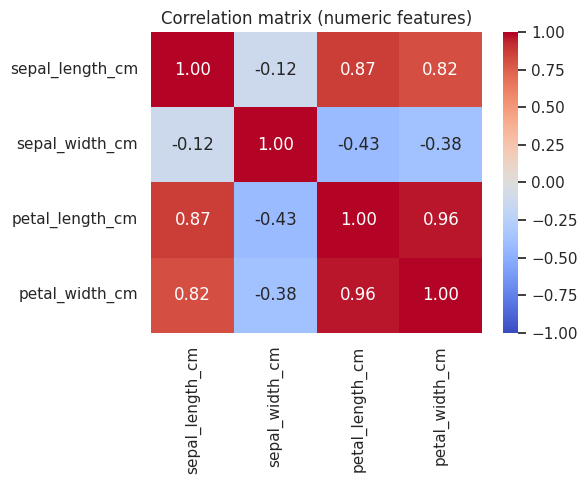

In [12]:
corr = df_clean[num_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()
corr


**Observation:** `petal_length_cm` and `petal_width_cm` are very strongly
correlated (r ≈ 0.96), and both correlate strongly with `sepal_length_cm`
(r ≈ 0.87 and 0.82). `sepal_width_cm` is the odd one out — weakly,
slightly *negatively* correlated with the other three. This means petal
length/width carry mostly overlapping information; a downstream model
likely wouldn't need both.

## 7. Outlier detection (IQR rule)

In [13]:
def iqr_outlier_count(s: pd.Series) -> int:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum())

{col: iqr_outlier_count(df_clean[col].dropna()) for col in num_cols}


{'sepal_length_cm': 0, 'sepal_width_cm': 4, 'petal_length_cm': 0, 'petal_width_cm': 0}

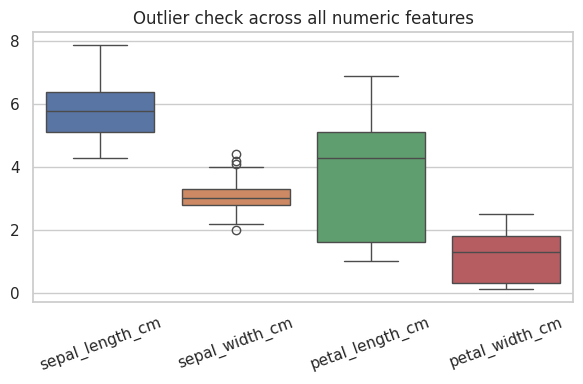

In [14]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_clean[num_cols])
plt.title("Outlier check across all numeric features")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Observation:** only `sepal_width_cm` shows any IQR outliers (2 points),
and they are mild — a couple of unusually wide/narrow sepals, not data
entry errors. No aggressive outlier removal is warranted here.

## 8. Automated profiling report (ydata-profiling)

In [15]:
# Generates report.html. Uses the real ydata-profiling library if it's
# installed; otherwise falls back to a lightweight custom HTML profiler
# with the same overview/per-column/correlation sections (see
# build_profile_report.py). Install with: pip install ydata-profiling
from build_profile_report import try_ydata_profiling, build_fallback_report

if not try_ydata_profiling(df_clean, "report.html"):
    build_fallback_report(df_clean, "report.html")

print("report.html written.")


report.html written.


## 9. Key insights\n\nSee `insights_summary.md` for the full write-up. Headline findings:

In [16]:
summary_points = [
    "petal_length_cm and petal_width_cm are near-duplicate signals (r=0.96) - one could likely be dropped without much information loss.",
    "setosa is linearly separable from the other two species on almost any single feature; versicolor/virginica overlap more.",
    "Classes are balanced (~50/50/50), so no resampling is needed for a future classification task.",
    "6 missing values were confined to petal_width_cm (~4% of rows) - handled with median imputation.",
    "1 duplicate row was found and removed.",
    "Only sepal_width_cm shows mild outliers (2 points) under the IQR rule - no aggressive filtering needed.",
]
for i, p in enumerate(summary_points, 1):
    print(f"{i}. {p}")


1. petal_length_cm and petal_width_cm are near-duplicate signals (r=0.96) - one could likely be dropped without much information loss.
2. setosa is linearly separable from the other two species on almost any single feature; versicolor/virginica overlap more.
3. Classes are balanced (~50/50/50), so no resampling is needed for a future classification task.
4. 6 missing values were confined to petal_width_cm (~4% of rows) - handled with median imputation.
5. 1 duplicate row was found and removed.
6. Only sepal_width_cm shows mild outliers (2 points) under the IQR rule - no aggressive filtering needed.
